In [16]:
# =============================================================================
# Is F2 (A998) really administered three times a year?
# =============================================================================
# Weekly count of DIFFERENT pupils who sat A998. ONE IMAGE PER ACADEMIC YEAR,
# and inside each image TWO axes -- northern hemisphere on top, southern below.
# If the test is administered in three "tongades" per course, each axis should
# show three separated blocks of weeks.
#
# Why two axes: the school year runs Sep -> Jun north of the equator and
# Feb -> Dec south of it, so pooling BR/CL with ES/MX/IT/US superimposes two
# different calendars on one time axis and smears the waves. The split is by
# LATITUDE only (Maria, 2026-08-14) -- see the .sql header for the exact
# region lists and for the two judgement calls it forces (Colombia's calendar A
# and Ecuador's Costa regime run southern-style years but sit on the northern
# axis, so their waves look displaced there).
#
# Scope decisions (full writeup in queries/a998_students_per_week_by_year.sql)
# -- this notebook deliberately applies NO analysis filters:
#   * all regions                 (split into two axes, none dropped)
#   * all ages                    (Decision #2 would undercount coverage)
#   * all packs, both operations, first statement of each pack-sitting INCLUDED
#     (Decision #7 not applied -- it could remove a pupil entirely)
# The question is "who was administered the test, and when", not "how well did
# they do", so every pupil with at least one A998 statement counts.
#
# Calendar window: both axes span Jan <Y> -> Dec <Y+1>, not Sep -> Jun, so that
# whichever hemisphere you look at, its whole course fits inside the window and
# the two axes stay directly comparable month for month.
#
# Three grains come back from one query, tagged by `grain` + `hemisphere`:
#   grain='week'                  -> distinct pupils that week   (the bars)
#   grain='year', hemisphere=N/S  -> distinct pupils that year   (per-axis note)
#   grain='year', hemisphere=all  -> distinct pupils, pooled
# The yearly numbers CANNOT be obtained by summing the weekly ones: a pupil who
# sits the test three times is counted in three weekly rows. Their ratio is
# printed below as `revisit_factor`.
#
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HERE = Path.cwd()          # descriptive/ -- run the notebook from its own folder
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

SQL_PATH  = HERE / "queries" / "a998_students_per_week_by_year.sql"
CACHE_DIR = HERE / "cache"

raw = cached_query(SQL_PATH, CACHE_DIR)
raw["week_start"] = pd.to_datetime(raw["week_start"])

# Fail loudly on a region the .sql could not classify, instead of drawing it
# nowhere (or, worse, folding it into the wrong hemisphere).
unknown = raw[raw["hemisphere"] == "unknown"]
if len(unknown):
    regions = sorted({r for s in unknown["regions"] for r in s.split(",")})
    raise ValueError(
        f"unclassified region(s) {regions} -- add them to the northern/southern "
        f"IN-lists in {SQL_PATH.name} before plotting"
    )

weekly = (raw[raw["grain"] == "week"]
          .drop(columns="grain")
          .sort_values(["academic_year", "hemisphere", "week_start"])
          .reset_index(drop=True))
yearly = (raw[raw["grain"] == "year"]
          .drop(columns=["grain", "week_start"])
          .set_index(["academic_year", "hemisphere"]))

print("A998 | bi_gold_prod.dm_research.fluency_test_statements | all regions, all ages, all packs")
print(f"{len(weekly):,} weekly rows | academic years {sorted(weekly['academic_year'].unique())}")
for hemi in ("northern", "southern"):
    regs = sorted({r for s in yearly.xs(hemi, level='hemisphere')["regions"] for r in s.split(",")})
    print(f"  {hemi:<9} {len(regs)} regions: {', '.join(regs)}")
print(f"cache -> {CACHE_DIR.relative_to(ROOT)}/")

A998 | bi_gold_prod.dm_research.fluency_test_statements | all regions, all ages, all packs
74 weekly rows | academic years [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
  northern  8 regions: CO-A, CO-B, EC-CO, EC-SI, ES, IT, MX, US
  southern  2 regions: BR, CL
cache -> descriptive\cache/


In [17]:
# --- coverage check before plotting anything ---------------------------------
# `revisit_factor` = (sum of the weekly distinct counts) / (distinct pupils in
# the year). It is NOT a data-quality metric, it is the answer to the question
# in miniature: if every pupil sits the test in exactly 3 different weeks the
# ratio is 3.0; if the test is really administered once, it is ~1.0. Values in
# between mean either partial coverage (not every pupil does all 3 waves) or a
# wave that spills over two calendar weeks (which inflates it).
cov = (weekly.groupby(["academic_year", "hemisphere"])
       .agg(weeks_with_data=("week_start", "size"),
            first_week=("week_start", "min"),
            last_week=("week_start", "max"),
            peak_week=("n_students", "max"),
            sum_of_weekly=("n_students", "sum")))

cov["distinct_pupils_year"] = yearly["n_students"]
cov["regions"] = yearly["n_regions"]
cov["revisit_factor"] = (cov["sum_of_weekly"] / cov["distinct_pupils_year"]).round(2)

pd.set_option("display.width", 220)
print(cov[["regions", "distinct_pupils_year", "sum_of_weekly", "revisit_factor",
           "weeks_with_data", "peak_week", "first_week", "last_week"]].to_string())

print("\npooled over both hemispheres (NOT northern + southern -- distinct counts do not add):")
print(yearly.xs("all", level="hemisphere")[["n_students", "n_regions", "regions"]].to_string())

# Sanity: a year whose weeks fall outside its own Jan<Y>-Dec<Y+1> window would be
# silently clipped by the plotting grid below, so flag it here instead.
for (y, hemi), g in weekly.groupby(["academic_year", "hemisphere"]):
    lo, hi = pd.Timestamp(year=y, month=1, day=1), pd.Timestamp(year=y + 1, month=12, day=31)
    out = g[(g["week_start"] < lo) | (g["week_start"] > hi)]
    if len(out):
        print(f"WARNING {y} {hemi}: {len(out)} week(s) outside the Jan {y}-Dec {y+1} window, "
              f"{out['n_students'].sum():,} pupil-weeks -- these will NOT be drawn: "
              f"{list(out['week_start'].dt.date)}")

                          regions  distinct_pupils_year  sum_of_weekly  revisit_factor  weeks_with_data  peak_week first_week  last_week
academic_year hemisphere                                                                                                                
2022          northern          3                104420         166300            1.59                9      61138 2023-04-17 2023-06-12
2023          northern          6                102947         103012            1.00                6      63670 2024-01-08 2024-02-12
2024          northern          7                192164         349854            1.82               16     119949 2024-01-22 2025-07-07
              southern          1                    20             20            1.00                2         15 2024-12-02 2024-12-09
2025          northern          8                228977         525576            2.30               27     120971 2025-06-09 2026-07-20
              southern          2        

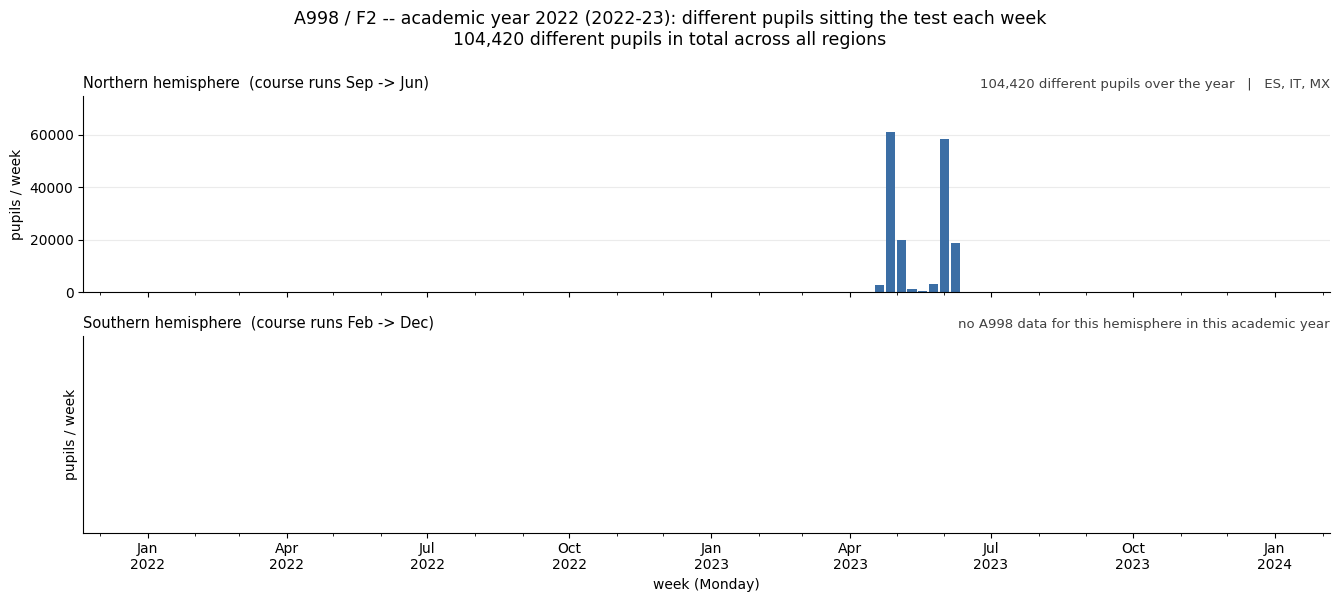

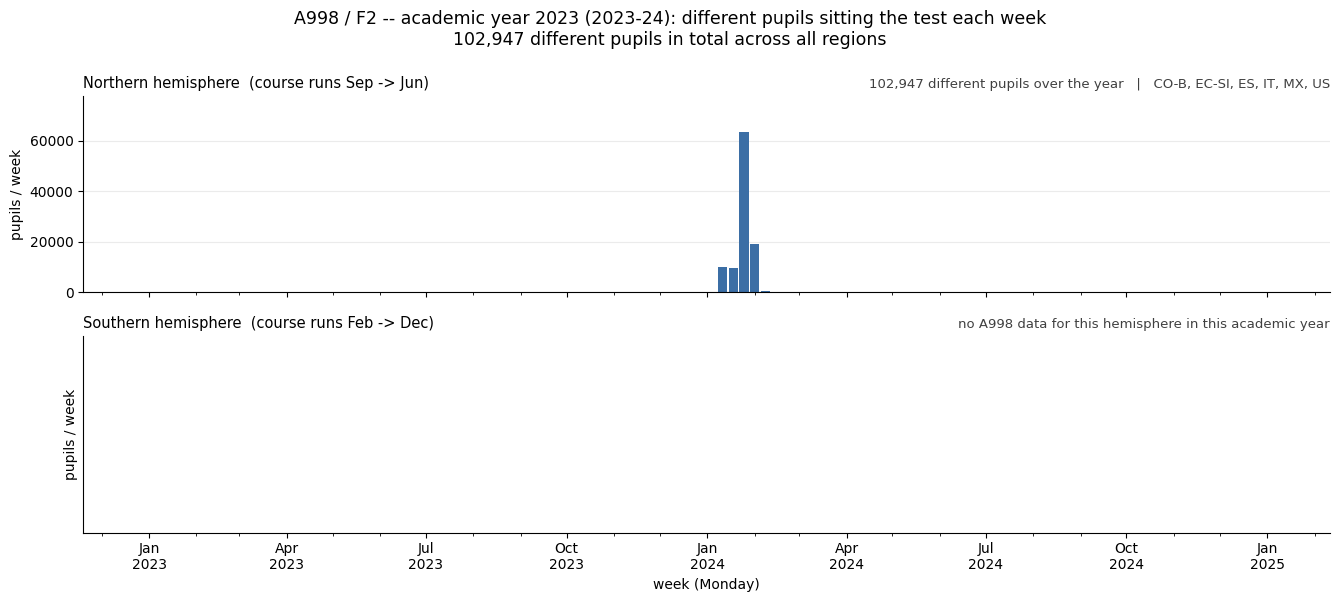

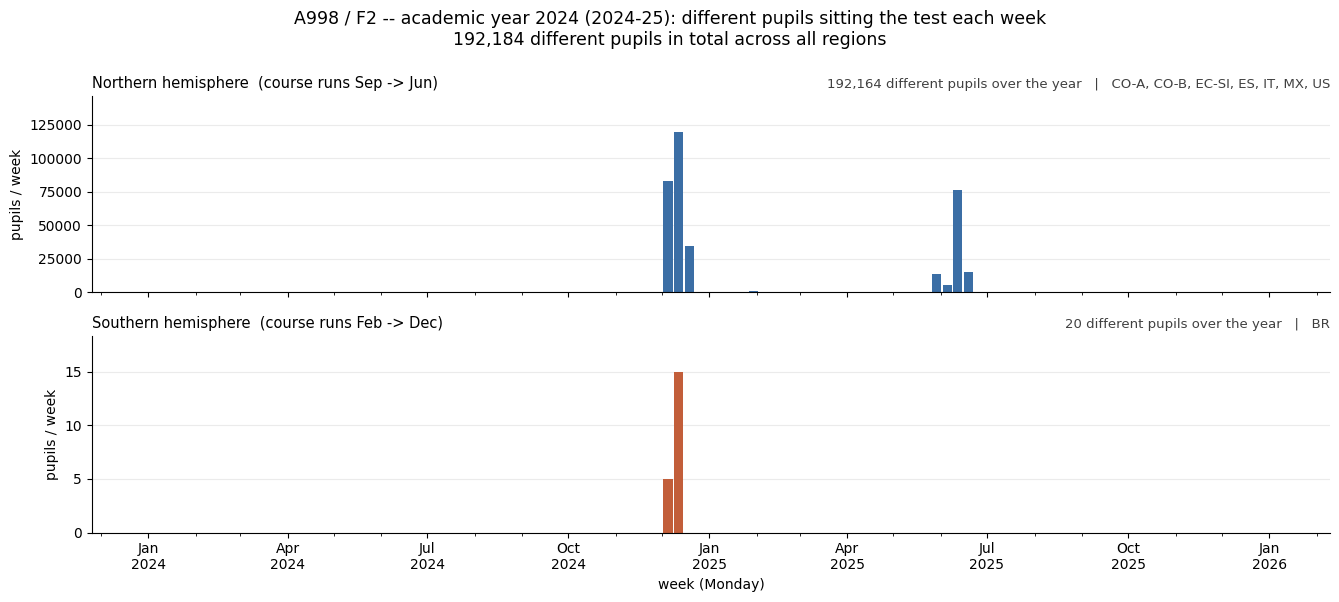

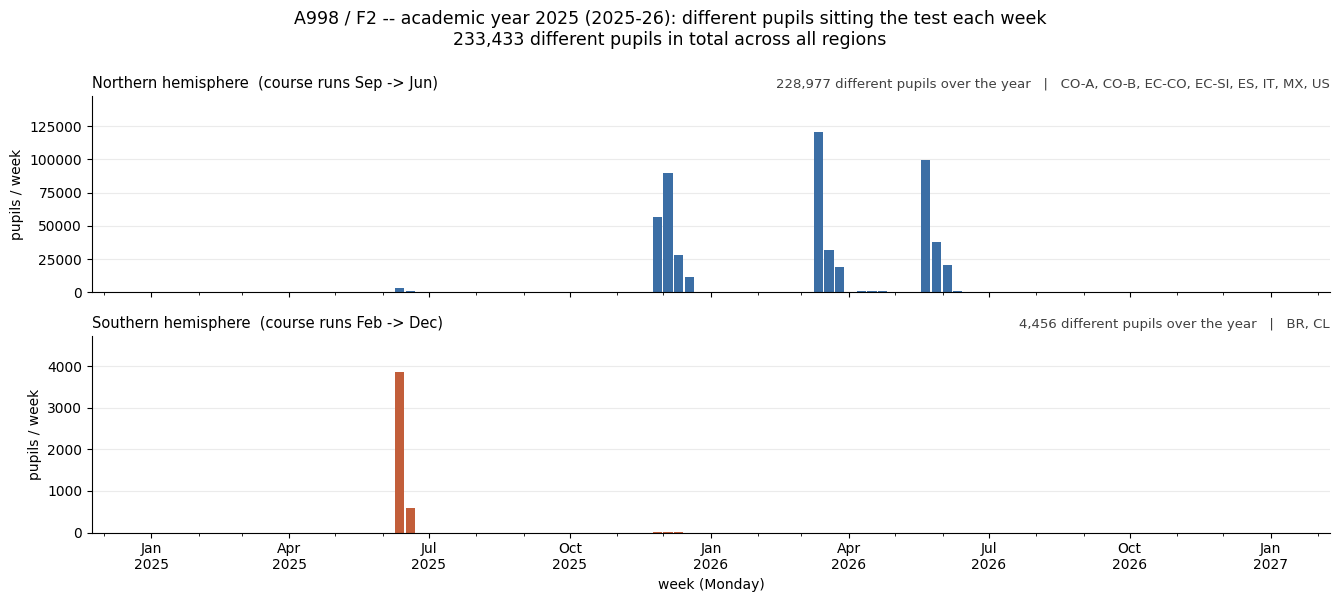

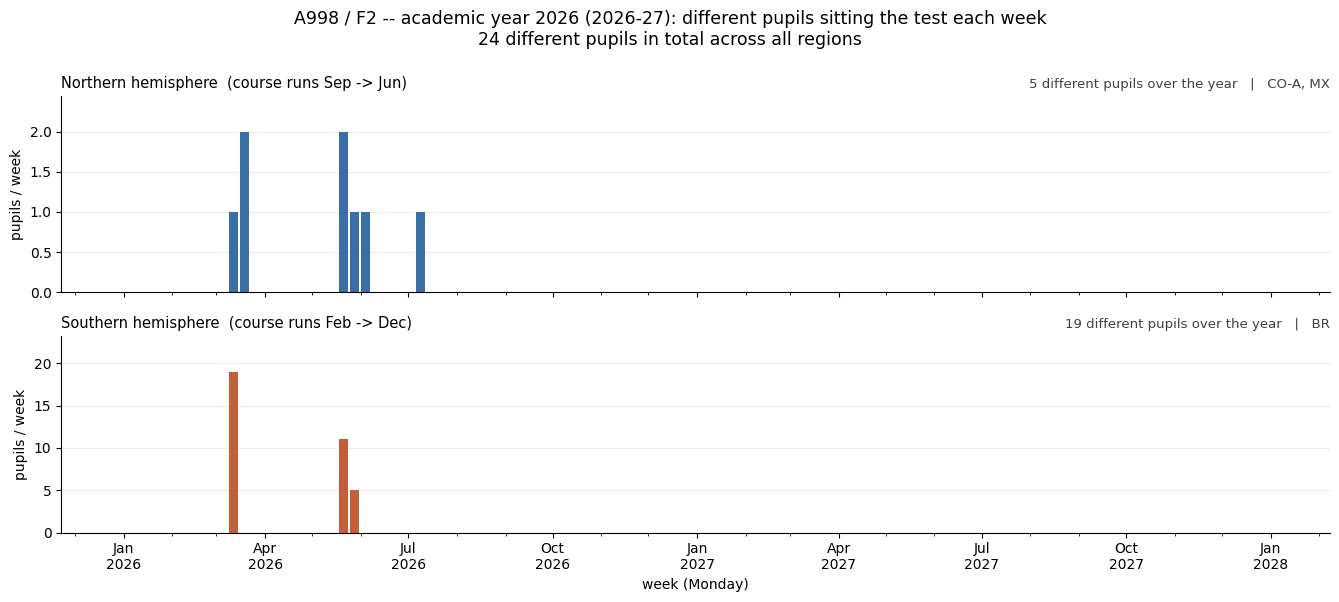

In [18]:
# --- weekly grid + one figure per academic year ------------------------------
# Every (year, hemisphere) series is reindexed onto a COMPLETE Monday grid
# covering Jan <Y> -> Dec <Y+1> and missing weeks are filled with 0. That is
# what gives every axis the same 2-calendar-year span without touching
# set_xlim: the zero weeks are real data points (nobody sat the test), so
# autoscale covers the whole window on its own. The two axes of a figure share
# that x-axis, so a northern wave and a southern wave in the same month line up
# vertically.
YEARS = sorted(weekly["academic_year"].unique())   # e.g. [2025] to plot one year
HEMIS = ["northern", "southern"]
HEMI_COLOR = {"northern": "#3b6ea5", "southern": "#c25e3a"}
HEMI_TITLE = {"northern": "Northern hemisphere  (course runs Sep -> Jun)",
              "southern": "Southern hemisphere  (course runs Feb -> Dec)"}

def full_week_grid(year):
    """Every Monday from the week containing 1 Jan <year> to 31 Dec <year+1>."""
    start = pd.Timestamp(year=year, month=1, day=1)
    start = start - pd.Timedelta(days=start.weekday())      # back up to Monday
    return pd.date_range(start, pd.Timestamp(year=year + 1, month=12, day=31), freq="W-MON")

def weekly_series(year, hemi):
    s = (weekly.loc[(weekly["academic_year"] == year) & (weekly["hemisphere"] == hemi)]
         .set_index("week_start")["n_students"].astype(float))
    return s.reindex(full_week_grid(year)).fillna(0.0)

def plot_year(year, waves=None, suffix=""):
    """One image for one academic year: northern axis on top, southern below."""
    fig, axes = plt.subplots(2, 1, figsize=(13.5, 6.0), sharex=True)

    for ax, hemi in zip(axes, HEMIS):
        s = weekly_series(year, hemi)
        has_data = s.values.max() > 0
        ax.bar(s.index, s.values, width=6.0, align="edge", color=HEMI_COLOR[hemi], linewidth=0)
        ax.set_ylim(0, max(s.values.max(), 1) * 1.22)   # headroom for labels (y only -- x autoscales)
        if not has_data:
            ax.set_yticks([])                            # an empty axis needs no 0.0-1.2 scale

        if waves and (year, hemi) in waves:
            for i, (w0, w1) in enumerate(waves[(year, hemi)], start=1):
                ax.axvspan(w0, w1 + pd.Timedelta(days=7), color="#d97706", alpha=0.12, linewidth=0)
                ax.text(w0 + (w1 - w0) / 2 + pd.Timedelta(days=3.5), ax.get_ylim()[1] * 0.99,
                        f"T{i}", ha="center", va="top", fontsize=9, color="#b45309", weight="bold")

        # The yearly headline goes in a RIGHT-aligned axis title rather than a
        # floating text box: the northern course sits in the middle of the
        # Jan<Y>-Dec<Y+1> window, so any in-axes box eventually collides with a
        # wave. A title can never overlap the bars.
        if (year, hemi) in yearly.index and has_data:
            row = yearly.loc[(year, hemi)]
            note = (f"{int(row['n_students']):,} different pupils over the year"
                    f"   |   {row['regions'].replace(',', ', ')}")
        else:
            note = "no A998 data for this hemisphere in this academic year"

        ax.set_ylabel("pupils / week")
        ax.set_title(HEMI_TITLE[hemi], loc="left", fontsize=10.5)
        ax.set_title(note, loc="right", fontsize=9.5, color="0.25")
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    axes[-1].xaxis.set_minor_locator(mdates.MonthLocator())
    axes[-1].set_xlabel("week (Monday)")

    pooled = int(yearly.loc[(year, "all"), "n_students"]) if (year, "all") in yearly.index else 0
    fig.suptitle(f"A998 / F2 -- academic year {year} ({year}-{str(year + 1)[-2:]}): "
                 f"different pupils sitting the test each week\n"
                 f"{pooled:,} different pupils in total across all regions",
                 y=0.995, fontsize=12.5)
    fig.tight_layout()
    fname = f"a998_students_per_week_{year}{suffix}"
    fig.savefig(HERE / "plots" / f"{fname}.png", dpi=130, bbox_inches="tight")
    fig.savefig(HERE / "plots" / f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    return fig

for year in YEARS:
    plot_year(year)

threshold = 15% of that axis's peak week | gap tolerance = 2 wk | min length = 2 wk

 academic_year hemisphere wave       from         to  weeks  peak_week  pupil_weeks
          2022   northern   T1 2023-04-24 2023-05-07      2      61138        81143
          2022   northern   T2 2023-05-29 2023-06-11      2      58444        77343
          2023   northern   T1 2024-01-08 2024-02-04      4      63670       102346
          2024   northern   T1 2024-12-02 2024-12-22      3     119949       237447
          2024   southern   T1 2024-12-02 2024-12-15      2         15           20
          2025   northern   T1 2025-11-24 2025-12-14      3      89426       174369
          2025   northern   T2 2026-03-09 2026-03-29      3     120971       171442
          2025   northern   T3 2026-05-18 2026-06-07      3      99440       158086
          2025   southern   T1 2025-06-09 2025-06-22      2       3871         4453
          2026   northern   T1 2026-03-09 2026-03-22      2          2     

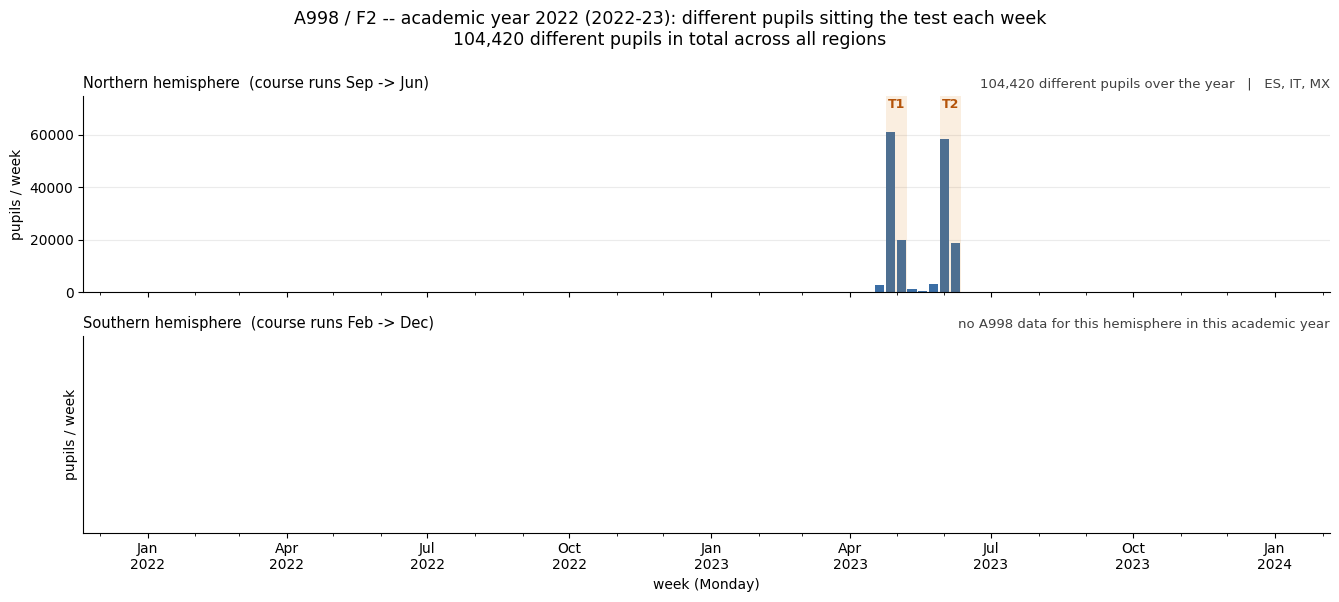

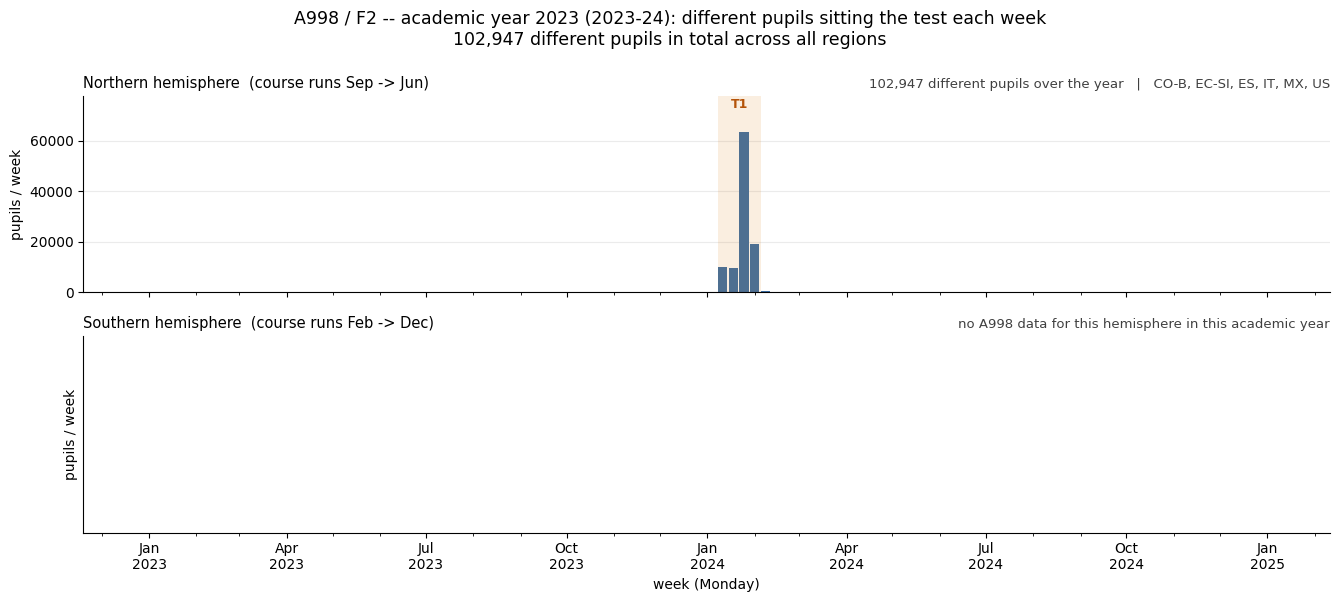

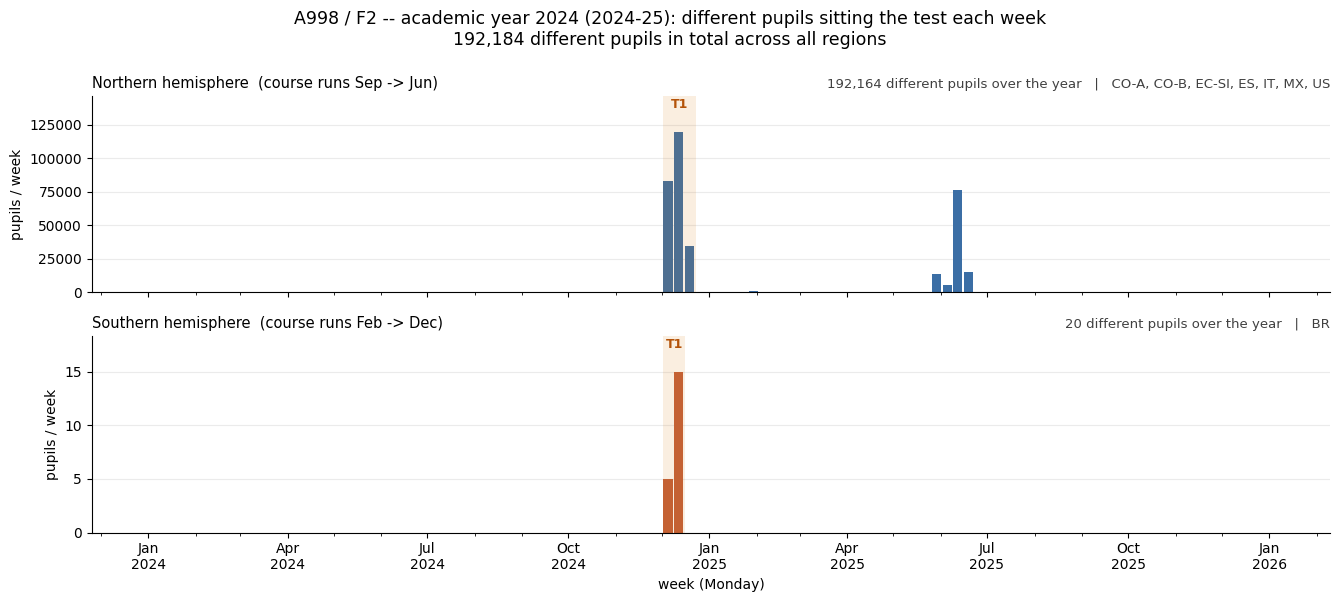

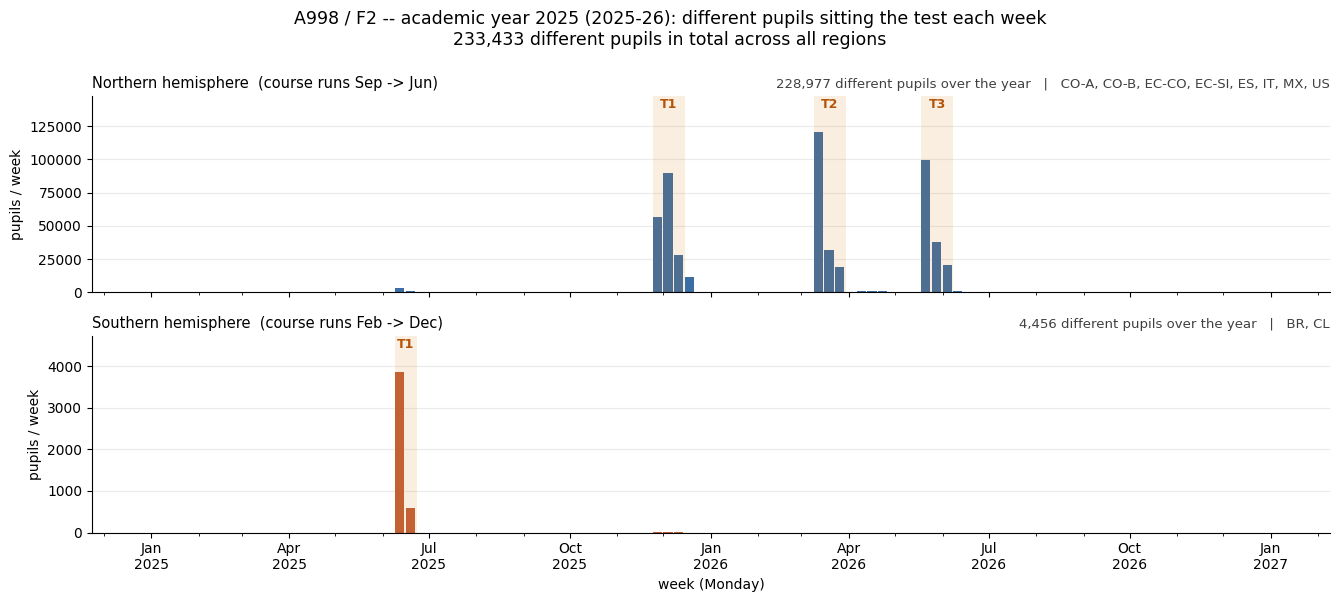

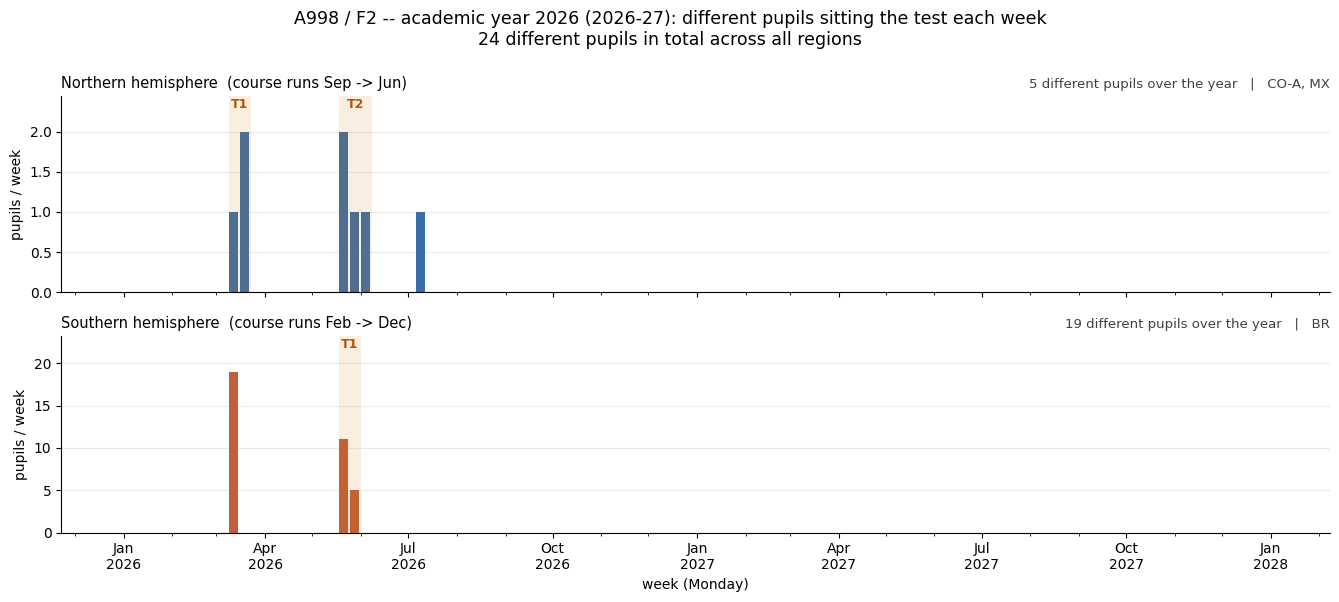

In [19]:
# --- how many waves per year and hemisphere, actually? -----------------------
# A "wave" here is a run of consecutive weeks whose pupil count stays above
# WAVE_THRESHOLD x that axis's peak week, tolerating GAP_WEEKS quiet weeks in
# the middle (a school holiday inside a tongada should not split it in two).
# The threshold is per (year, hemisphere), so a small southern sample is not
# judged against a large northern peak.
# This is a descriptive rule of thumb, not a model: change the three constants
# and the wave count changes, so read the shaded figures, do not trust the
# number alone. `pupil_weeks` inside a wave is a SUM of weekly distinct counts,
# so it is an upper bound on the distinct pupils of that wave, not a headcount
# -- the query would need a fourth grain to give a true per-wave distinct count.
WAVE_THRESHOLD = 0.15    # fraction of that axis's peak week
GAP_WEEKS      = 2       # quiet weeks tolerated inside one wave
MIN_WAVE_WEEKS = 2       # a single isolated week is noise, not a tongada

def find_waves(s, threshold=WAVE_THRESHOLD, gap=GAP_WEEKS, min_weeks=MIN_WAVE_WEEKS):
    if s.values.max() <= 0:
        return []
    active = s.index[s.values >= threshold * s.values.max()]
    runs, cur = [], [active[0], active[0]]
    for t in active[1:]:
        if (t - cur[1]).days <= 7 * (gap + 1):
            cur[1] = t
        else:
            runs.append(tuple(cur)); cur = [t, t]
    runs.append(tuple(cur))
    return [(a, b) for a, b in runs if (b - a).days / 7 + 1 >= min_weeks]

waves, rows = {}, []
for year in YEARS:
    for hemi in HEMIS:
        s = weekly_series(year, hemi)
        waves[(year, hemi)] = find_waves(s)
        for i, (w0, w1) in enumerate(waves[(year, hemi)], start=1):
            seg = s.loc[w0:w1]
            rows.append({"academic_year": year, "hemisphere": hemi, "wave": f"T{i}",
                         "from": w0.date(), "to": (w1 + pd.Timedelta(days=6)).date(),
                         "weeks": int((w1 - w0).days / 7 + 1),
                         "peak_week": int(seg.max()), "pupil_weeks": int(seg.sum())})

wave_tbl = pd.DataFrame(rows)
print(f"threshold = {WAVE_THRESHOLD:.0%} of that axis's peak week | gap tolerance = {GAP_WEEKS} wk | "
      f"min length = {MIN_WAVE_WEEKS} wk\n")
print(wave_tbl.to_string(index=False) if len(wave_tbl) else "no waves detected")

print("\nwaves detected per academic year x hemisphere:")
for year in YEARS:
    counts = "  ".join(f"{h}={len(waves[(year, h)])}" for h in HEMIS)
    print(f"  {year}:  {counts}")

for year in YEARS:
    plot_year(year, waves=waves, suffix="_waves")

In [20]:
# =============================================================================
# Which pack is administered at which age -- and is each pack drawn uniformly?
# =============================================================================
# A pack is a FIXED SET of facts (the U Pack of PC-A998; pack 14 = tables 2,5 /
# 16 = 2,4,5,8 / 20 = 2-9 / 32 = div 2,4,5 / 37 = div 2-9 / 39 = 0-9 both ops).
# Inside a sitting the app draws items from that set for ~120 s. If the draw is
# uniform, every fact of the pack should accumulate the same number of
# presentations, up to sampling noise. These cells check that.
#
# Query grain: (academic_year_id, activity_pack, classroom_course_age, op_type,
# fact) -- see queries/a998_fact_frequency_by_pack_age.sql. The academic year is
# in the grain ON PURPOSE: pack content is not stable across years (pack 20 also
# served the eight "a x 1" facts in ES_2022 and in no other year), so pooling
# years mixes two pack definitions and a legacy fact then looks like a rare one.
#
# Same no-filter stance as the rest of this notebook: all regions, all years,
# all ages, both operations, every answer, first statement included. The
# question is what was ADMINISTERED. n_excl_first is carried as its own column
# so the first item of a sitting can be checked separately.
FACT_SQL = HERE / "queries" / "a998_fact_frequency_by_pack_age.sql"

facts_raw = cached_query(FACT_SQL, CACHE_DIR)

# age: keep the NULL-age rows (a sitting whose classroom has no course age) as
# -1 instead of dropping them -- they are real administrations.
facts_raw["age"] = facts_raw["classroom_course_age"].fillna(-1).astype(int)
for c in ("n", "n_excl_first", "n_pupils"):
    facts_raw[c] = facts_raw[c].astype("int64")

# colours defined here on purpose: these cells must not depend on the constants
# of the weekly-wave cells above, which get renamed as that figure evolves.
FACT_BAR   = "#3b6ea5"
BAND_COLOR = "#d97706"

def age_label(a):
    return "n/a" if a < 0 else str(a)

print(f"{len(facts_raw):,} rows | {facts_raw['n'].sum():,} statements | "
      f"packs {sorted(facts_raw['activity_pack'].unique())} | "
      f"{facts_raw['academic_year_id'].nunique()} academic_year_ids | "
      f"{facts_raw['region'].nunique()} regions | "
      f"ages {sorted(map(age_label, facts_raw['age'].unique()))}")

# --- which pack was administered at which age -------------------------------
admin = (facts_raw
         .groupby(["activity_pack", "age"], as_index=False)
         .agg(n_statements=("n", "sum"),
              n_facts=("fact", "nunique"),
              n_years=("academic_year_id", "nunique"),
              n_regions=("region", "nunique"),
              ops=("op_type", lambda s: "+".join(sorted(set(x[:4] for x in s))))))
admin["pct_of_pack"] = (100 * admin["n_statements"]
                        / admin.groupby("activity_pack")["n_statements"].transform("sum")).round(1)
admin["age"] = admin["age"].map(age_label)

pd.set_option("display.width", 200)
print("\n--- packs x ages: what was actually administered "
      "(pct_of_pack = share of that pack's statements) ---")
print(admin.sort_values(["activity_pack", "n_statements"], ascending=[True, False])
      .to_string(index=False))

# n_facts above is the pooled fact-set size. It is bigger than the per-year one
# wherever pack content changed between years -- the next cell says where.

23,894 rows | 27,422,426 statements | packs [np.int32(14), np.int32(16), np.int32(20), np.int32(32), np.int32(37), np.int32(39)] | 30 academic_year_ids | 10 regions | ages ['10', '11', '12', '13', '14', '15', '4', '5', '6', '7', '8', '9', 'n/a']

--- packs x ages: what was actually administered (pct_of_pack = share of that pack's statements) ---
 activity_pack age  n_statements  n_facts  n_years  n_regions       ops  pct_of_pack
            14   8       2389703       18       14          7      mult         98.9
            14   9         14068       18        6          4      mult          0.6
            14  10          7035       18        4          3      mult          0.3
            14  11          4221       18        4          3      mult          0.2
            14   7          1559       18        6          5      mult          0.1
            14   6           438       18        3          2      mult          0.0
            14 n/a           211       18        2       

In [21]:
# --- fact-set stability, and the uniformity summary ---------------------------
# Two things have to be separated before any histogram can be read:
#   (1) facts that are NOT really part of the pack at that age (present in one
#       academic year only, or a handful of presentations). Pooled, they look
#       like severely under-drawn facts and they dominate any dispersion
#       measure. RARE_RATIO flags them.
#   (2) genuine non-uniformity among the facts that ARE in the pack.
#
# cv_excess is the headline number, not the p-value. Under a uniform draw each
# count is ~Binomial(total, 1/n_facts), so the coefficient of variation across
# facts should be cv_null = sqrt((1 - 1/n_facts) / expected). cv_excess =
# cv_observed / cv_null: 1.0 = exactly as even as chance allows, 2.0 = twice as
# spread out as a uniform draw. A chi-square p-value is useless here -- with
# 10^4-10^5 presentations per fact a 1% deviation is "significant" -- so chisq
# is reported as chisq/df instead (1.0 under the null, and it equals
# cv_excess^2 up to the n_facts/(n_facts-1) factor).
RARE_RATIO = 0.25    # a fact drawn < 25% of its cell's expected count is not "in the pack"
MIN_TOTAL  = 20_000  # a (pack, age, op_type) cell needs this many statements to be read
VALUE      = "n"     # switch to "n_excl_first" to drop statement_idx = 0 (Decision #7)

CELL_KEYS = ["activity_pack", "age", "op_type"]
FACT_KEYS = ["fact", "operand_1", "operand_2"]   # operands carried so panels can order by them

def with_expected(long, keys, value=VALUE):
    """Attach n_facts / total / expected / ratio / z to a per-fact frame."""
    out = long.copy()
    g = out.groupby(keys)[value]
    out["n_facts"]  = g.transform("size")
    out["total"]    = g.transform("sum")
    out["expected"] = out["total"] / out["n_facts"]
    out["ratio"]    = out[value] / out["expected"]
    p = 1.0 / out["n_facts"]
    out["sd_null"]  = np.sqrt(out["total"] * p * (1 - p))   # Binomial(total, p)
    out["z"]        = (out[value] - out["expected"]) / out["sd_null"]
    return out

def summarize(long, keys, value=VALUE):
    """One row per cell. A cell with a single fact has no dispersion to measure
    (df = 0, cv_null = 0), so its statistics are NaN rather than a crash -- such
    cells are real (pack 37 at age 5 has one single distinct operation) and they
    must survive into the table so the tiny cells stay visible."""
    rows = []
    for key, g in long.groupby(keys):
        key = key if isinstance(key, tuple) else (key,)
        k, total = int(g["n_facts"].iloc[0]), int(g["total"].iloc[0])
        exp = total / k
        degenerate = k < 2 or exp == 0
        cv_obs  = np.nan if degenerate else g[value].std(ddof=1) / g[value].mean()
        cv_null = np.nan if degenerate else np.sqrt((1 - 1 / k) / exp)
        chisq   = np.nan if degenerate else float(((g[value] - exp) ** 2 / exp).sum())
        rows.append(dict(zip(keys, key),
                         n_facts=k, total=total, expected=round(exp, 1),
                         min_ratio=round(g["ratio"].min(), 3),
                         max_ratio=round(g["ratio"].max(), 3),
                         cv=np.round(cv_obs, 4),
                         cv_null=np.round(cv_null, 4),
                         cv_excess=np.round(cv_obs / cv_null, 1),
                         chisq_over_df=np.round(chisq / (k - 1), 1) if k > 1 else np.nan))
    return pd.DataFrame(rows).sort_values(keys).reset_index(drop=True)

# per-year first: this is the honest fact set of a pack in a given year
by_year = with_expected(
    facts_raw.groupby(["academic_year_id"] + CELL_KEYS + FACT_KEYS, as_index=False)[VALUE].sum(),
    ["academic_year_id"] + CELL_KEYS)

rare = (by_year[(by_year["ratio"] < RARE_RATIO) & (by_year["total"] >= MIN_TOTAL)]
        .sort_values(VALUE, ascending=False))
rare_facts = set(zip(rare["activity_pack"], rare["age"], rare["fact"]))

print(f"--- facts drawn < {RARE_RATIO:.0%} of their cell's expected count "
      f"(cells with >= {MIN_TOTAL:,} statements) ---")
if len(rare):
    print(rare[["academic_year_id", "activity_pack", "age", "fact", VALUE,
                "expected", "ratio"]].head(30).to_string(index=False))
    print(f"{len(rare)} (year, pack, age, fact) combinations; "
          f"{len(rare_facts)} distinct (pack, age, fact). These are excluded from "
          f"the 'core set' rows below and drawn hollow in the figures.")
else:
    print("none -- every fact of every pack is drawn at a comparable rate")

# pooled over years and regions, all facts vs core set only
pooled_all = with_expected(
    facts_raw.groupby(CELL_KEYS + FACT_KEYS, as_index=False)[VALUE].sum(), CELL_KEYS)
core_mask = ~pd.Series(list(zip(pooled_all["activity_pack"], pooled_all["age"],
                               pooled_all["fact"])), index=pooled_all.index).isin(rare_facts)
pooled_core = with_expected(pooled_all.loc[core_mask, CELL_KEYS + FACT_KEYS + [VALUE]], CELL_KEYS)

summary_all  = summarize(pooled_all,  CELL_KEYS)
summary_core = summarize(pooled_core, CELL_KEYS)
summary = (summary_all
           .merge(summary_core[CELL_KEYS + ["n_facts", "cv_excess", "min_ratio", "max_ratio"]],
                  on=CELL_KEYS, suffixes=("", "_core"), how="left")   # left: keep cells
           .query("total >= @MIN_TOTAL"))                             # with no core facts left

print(f"\n--- uniformity per (pack, age, op_type), years and regions pooled, "
      f"value = {VALUE}, cells with >= {MIN_TOTAL:,} statements ---")
print(summary.to_string(index=False))
print("\ncv_excess = 1 means as even as a uniform draw can be; > 1 means "
      "over-dispersed. *_core columns drop the rare facts flagged above.")

--- facts drawn < 25% of their cell's expected count (cells with >= 20,000 statements) ---
academic_year_id  activity_pack  age fact   n   expected    ratio
         ES_2022             20    8  5×1 388 12668.0875 0.030628
         ES_2022             20    8  6×1 372 12668.0875 0.029365
         ES_2022             20    8  9×1 372 12668.0875 0.029365
         ES_2022             20    8  7×1 371 12668.0875 0.029286
         ES_2022             20    8  8×1 369 12668.0875 0.029128
         ES_2022             20    8  3×1 368 12668.0875 0.029049
         ES_2022             20    8  2×1 363 12668.0875 0.028655
         ES_2022             20    8  4×1 354 12668.0875 0.027944
         ES_2022             20    9  5×1   8   313.8375 0.025491
         ES_2022             20    9  4×1   7   313.8375 0.022305
         ES_2022             20    9  3×1   6   313.8375 0.019118
         ES_2022             20    9  2×1   6   313.8375 0.019118
         ES_2022             20    9  8×1   6   313

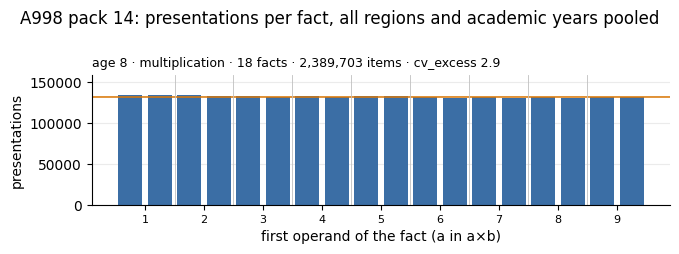

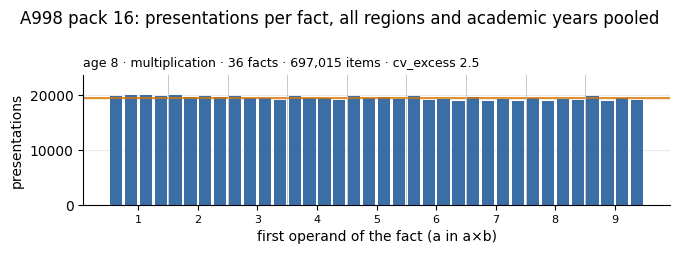

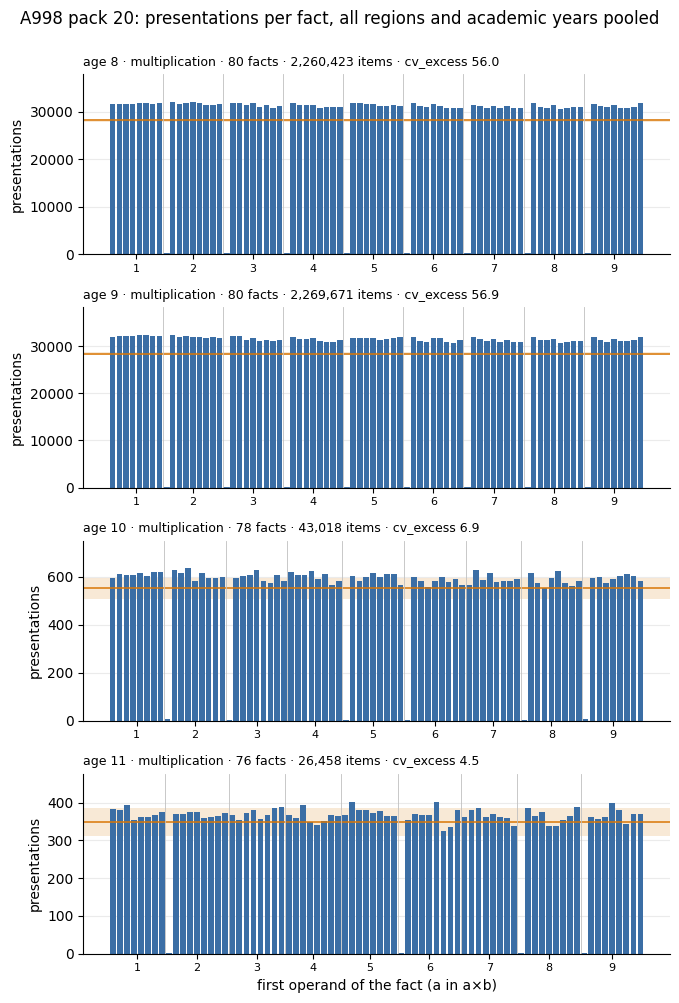

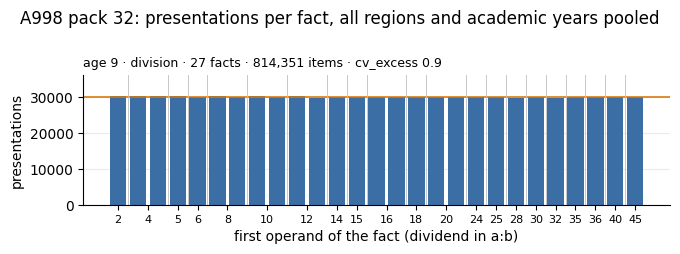

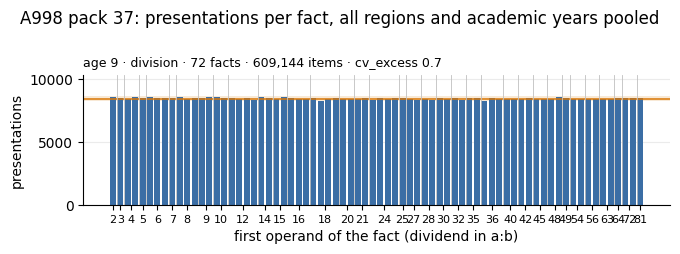

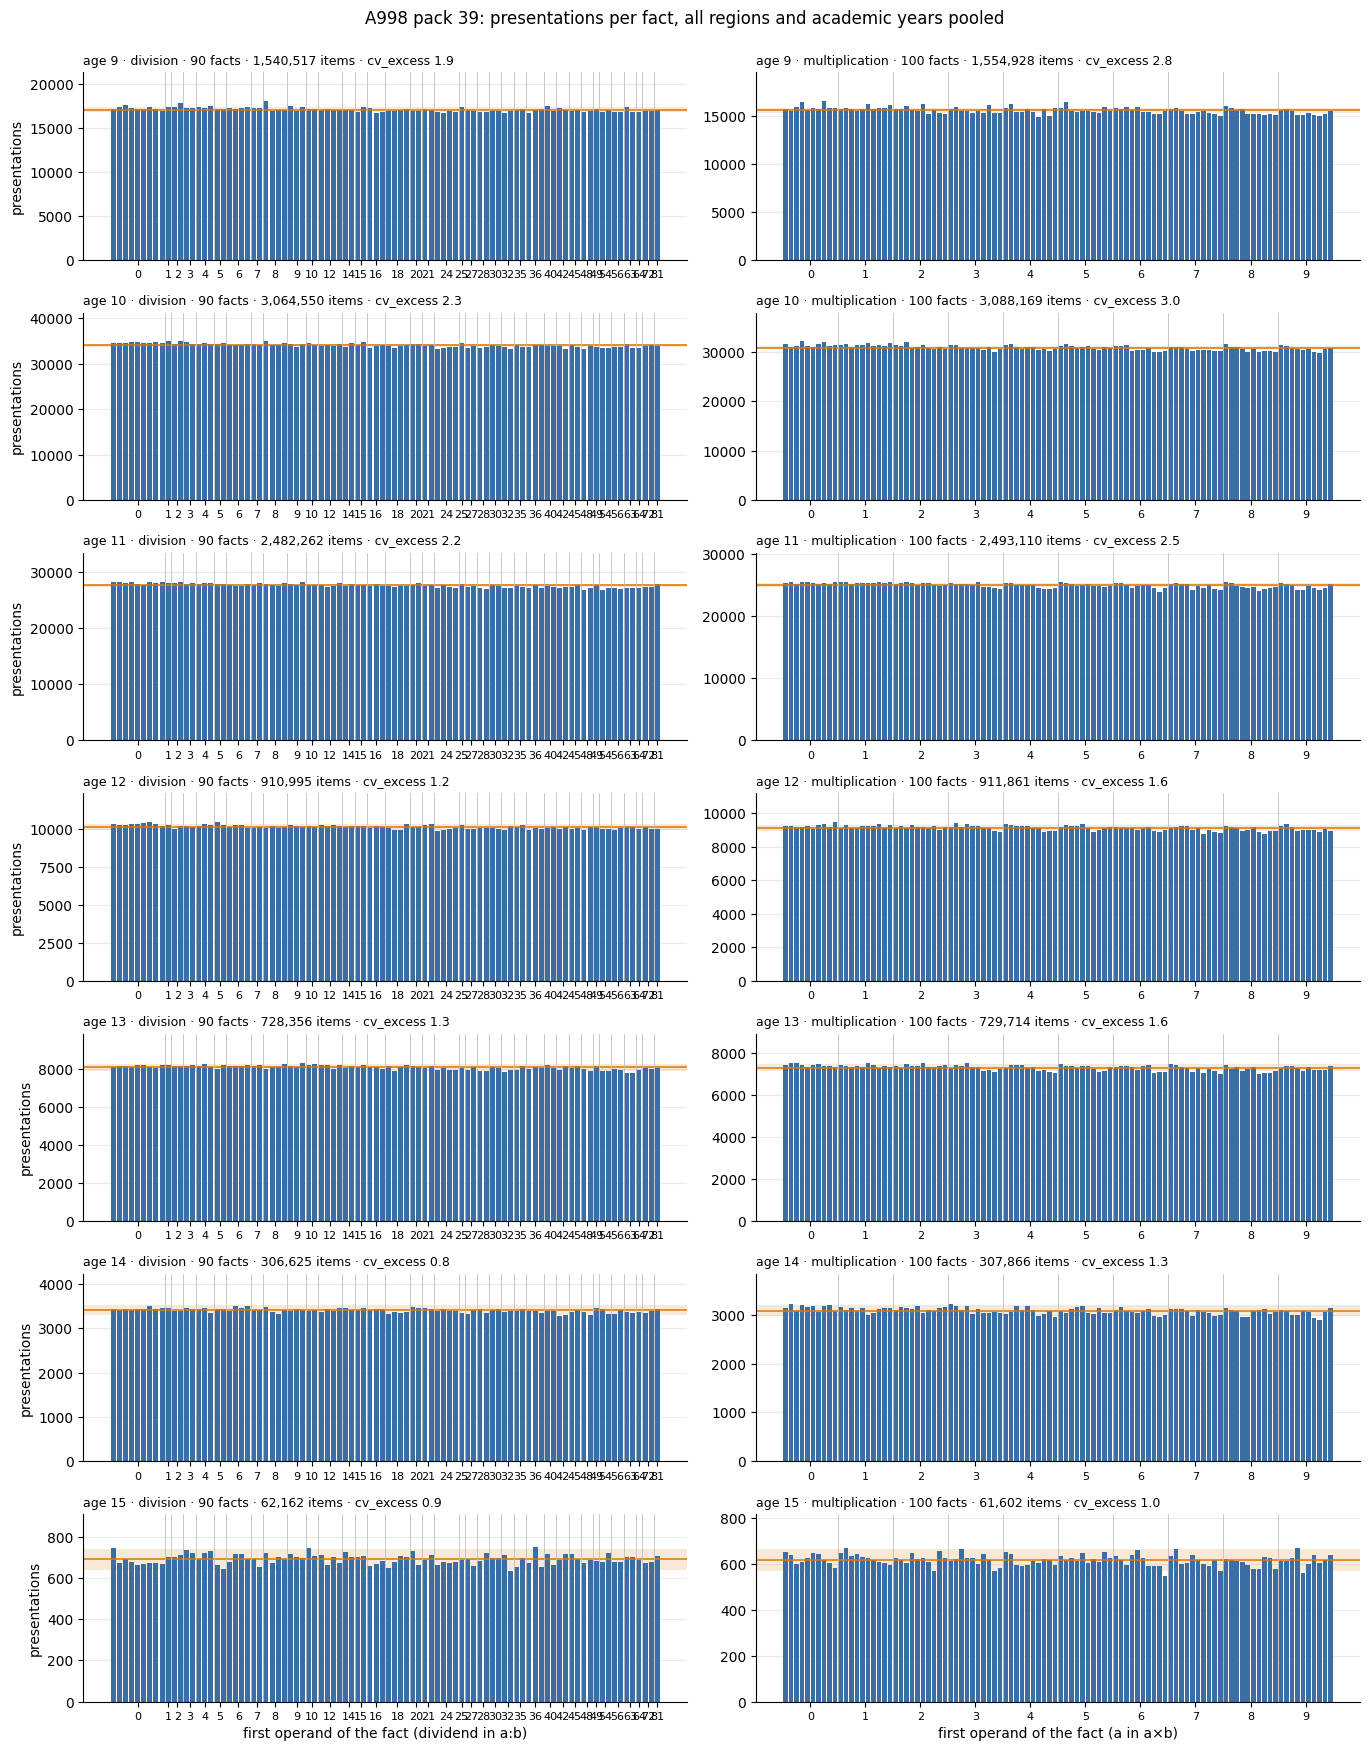

In [22]:
# --- the histograms: presentations per fact, one panel per (pack, age) --------
# Bars = observed presentations of each fact, ordered by (operand_1, operand_2)
# with a thin separator whenever operand_1 changes, so a whole under-drawn table
# is visible as a block. Solid line = total / n_facts (what uniform would give).
# Shaded band = expected +- 1.96 sd of a Binomial(total, 1/n_facts) draw, i.e.
# where 95% of facts should land if the draw really is uniform.
#
# The band is a REFERENCE, not a test. It assumes independent draws; real
# sittings draw without replacement (which narrows the true spread, so bars
# outside the band are still evidence) while pooling pupils, regions and years
# adds heterogeneity (which widens it). Read the shape, not the count of bars
# outside the band.
# Facts flagged rare in the previous cell are drawn hollow -- they are pack
# content that only existed in some years, not evidence of a biased draw.
def uniformity_panel(ax, g, value=VALUE, zoom=False):
    g = g.sort_values(["operand_1", "operand_2", "fact"]).reset_index(drop=True)
    x = np.arange(len(g))
    exp, sd = g["expected"].iloc[0], g["sd_null"].iloc[0]
    is_rare = [(p, a, f) in rare_facts
               for p, a, f in zip(g["activity_pack"], g["age"], g["fact"])]

    ax.axhspan(exp - 1.96 * sd, exp + 1.96 * sd, color=BAND_COLOR, alpha=0.16, linewidth=0)
    ax.axhline(exp, color=BAND_COLOR, linewidth=1.1)
    ax.bar(x[np.array(is_rare) == False], g.loc[[not r for r in is_rare], value],
           width=0.82, color=FACT_BAR, linewidth=0)
    if any(is_rare):
        ax.bar(x[np.array(is_rare)], g.loc[is_rare, value], width=0.82,
               facecolor="none", edgecolor=FACT_BAR, linewidth=0.7)

    # separators + labels at each change of the first operand
    bounds = np.flatnonzero(g["operand_1"].values[1:] != g["operand_1"].values[:-1]) + 1
    for b in bounds:
        ax.axvline(b - 0.5, color="0.75", linewidth=0.6)
    starts = np.concatenate([[0], bounds])
    ends   = np.concatenate([bounds, [len(g)]])
    ax.set_xticks((starts + ends - 1) / 2)
    ax.set_xticklabels(g["operand_1"].values[starts], fontsize=8)
    if zoom:      # crop to +-10% around expected: shows the SHAPE of small
        ax.set_ylim(exp * 0.9, exp * 1.1)   # deviations; rare facts run off the bottom
    else:
        ax.set_ylim(0, max(g[value].max(), exp + 3 * sd) * 1.18)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

def plot_pack(pack, long=None, value=VALUE, min_total=MIN_TOTAL, zoom=False):
    long = pooled_all if long is None else long
    cells = [(a, o) for (a, o), g in long[long["activity_pack"] == pack].groupby(["age", "op_type"])
             if g["total"].iloc[0] >= min_total]
    if not cells:
        print(f"pack {pack}: no (age, op_type) cell reaches {min_total:,} statements")
        return None
    ages     = sorted({a for a, _ in cells})
    op_types = sorted({o for _, o in cells})
    fig, axes = plt.subplots(len(ages), len(op_types), squeeze=False,
                             figsize=(6.9 * len(op_types), 2.5 * len(ages)))
    for i, age in enumerate(ages):
        for j, op in enumerate(op_types):
            ax = axes[i][j]
            g = long[(long["activity_pack"] == pack) & (long["age"] == age)
                     & (long["op_type"] == op)]
            if not len(g) or g["total"].iloc[0] < min_total:
                ax.set_axis_off()
                continue
            uniformity_panel(ax, g, value, zoom=zoom)
            s = summary_all[(summary_all["activity_pack"] == pack) & (summary_all["age"] == age)
                            & (summary_all["op_type"] == op)].iloc[0]
            ax.set_title(f"age {age_label(age)} · {op} · {s['n_facts']} facts · "
                         f"{s['total']:,} items · cv_excess {s['cv_excess']}",
                         loc="left", fontsize=9)
            if j == 0:
                ax.set_ylabel("presentations")
    for j, op in enumerate(op_types):
        axes[-1][j].set_xlabel("first operand of the fact "
                               f"({'a in a×b' if op == 'multiplication' else 'dividend in a:b'})")
    fig.suptitle(f"A998 pack {pack}: presentations per fact, all regions and academic years pooled",
                 y=0.998, fontsize=12)
    fig.tight_layout()
    fname = f"a998_fact_uniformity_pack{pack}" + ("_zoom" if zoom else "")
    fig.savefig(HERE / "plots" / f"{fname}.png", dpi=130, bbox_inches="tight")
    fig.savefig(HERE / "plots" / f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    return fig

for _pack in sorted(pooled_all["activity_pack"].unique()):
    plot_pack(_pack)

# Same panels cropped to expected +-10%: at these sample sizes the full-scale
# bars all look identical, so this is the view that shows whether the small
# deviations have structure (a whole table low, a gradient across operands).
# plot_pack(39, zoom=True)

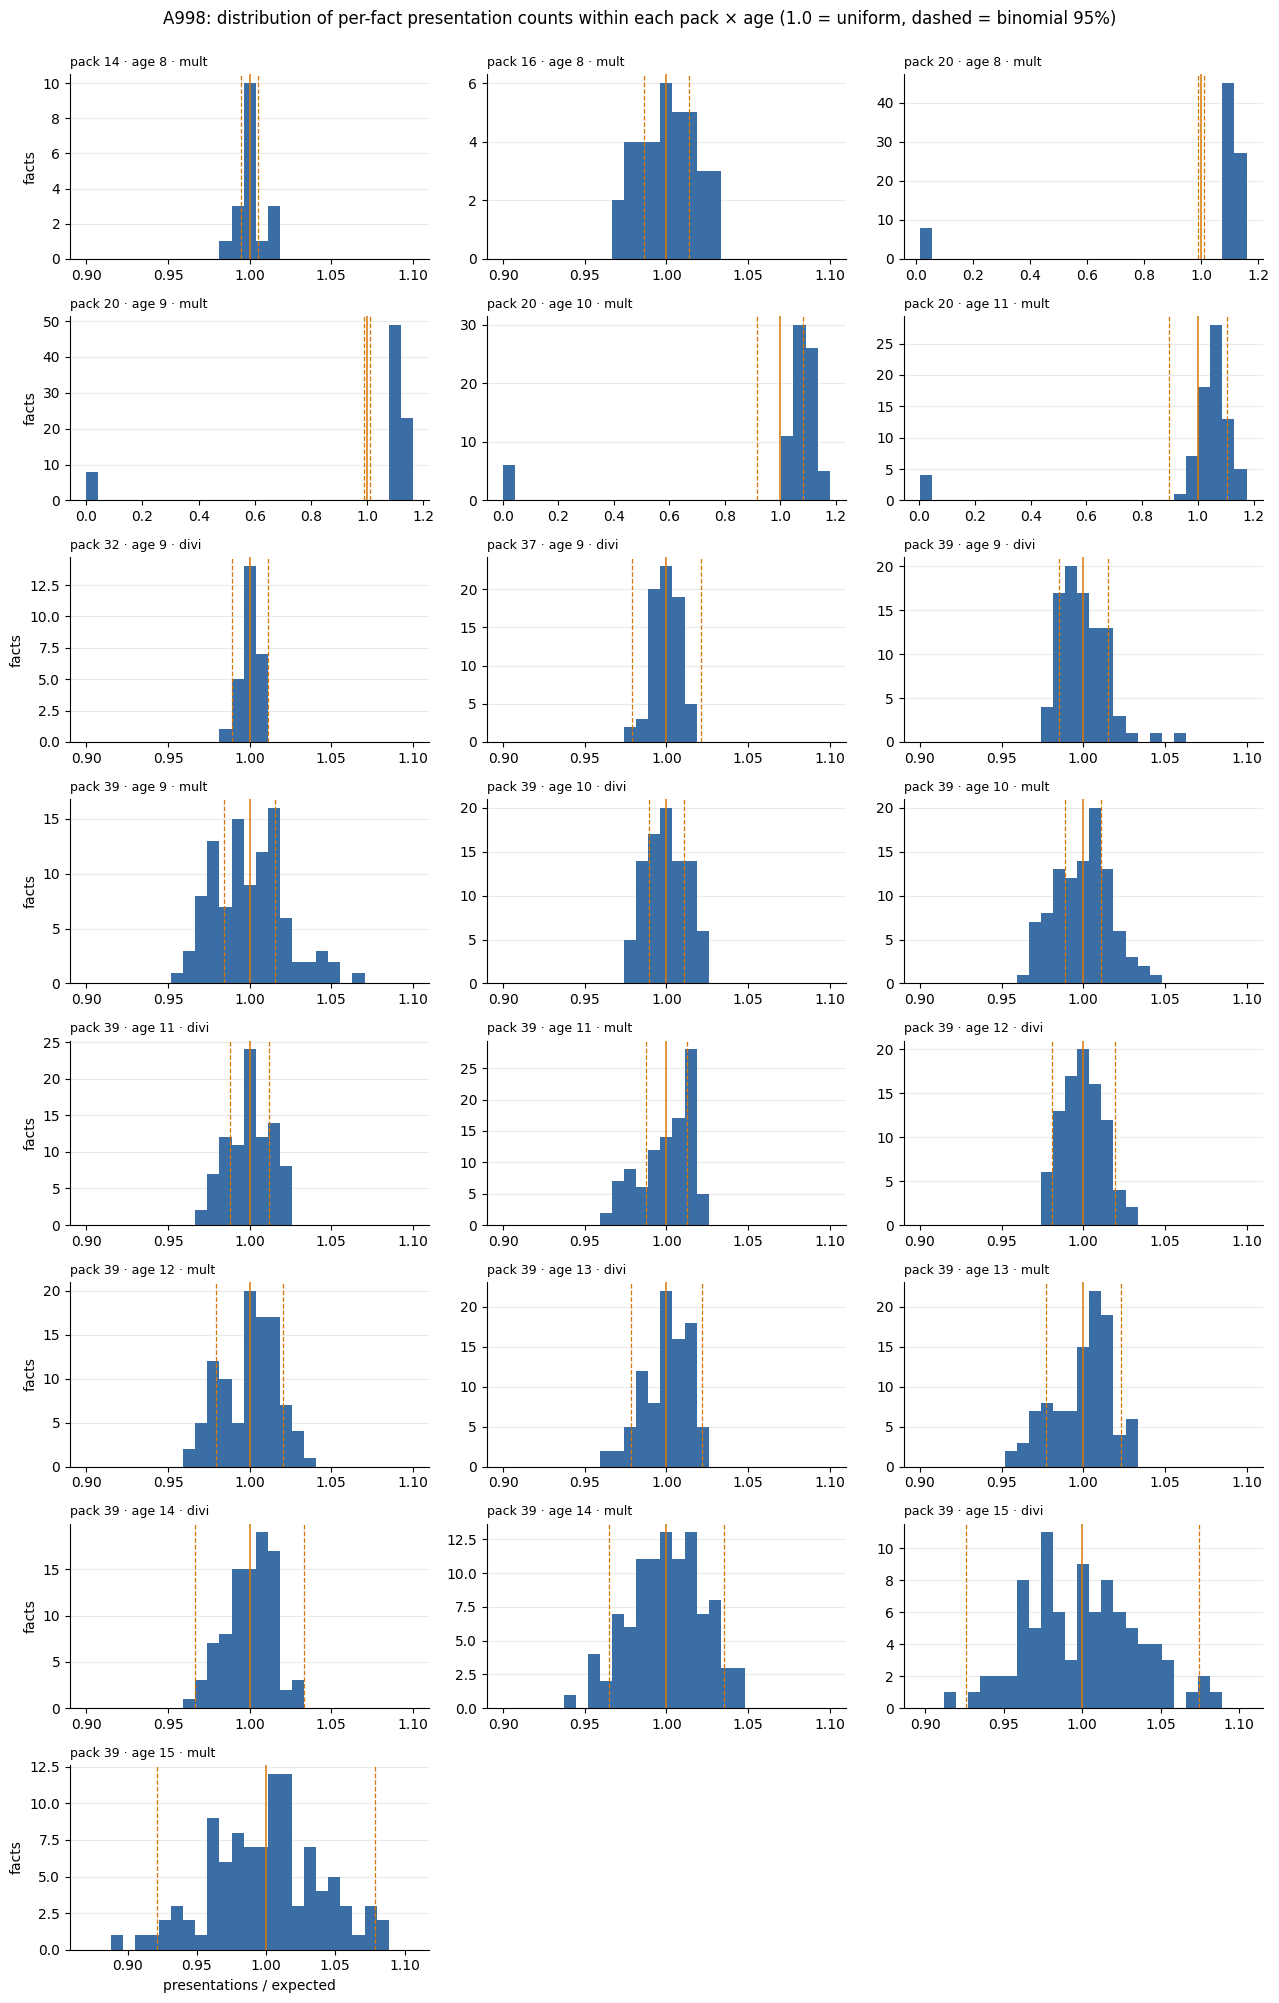

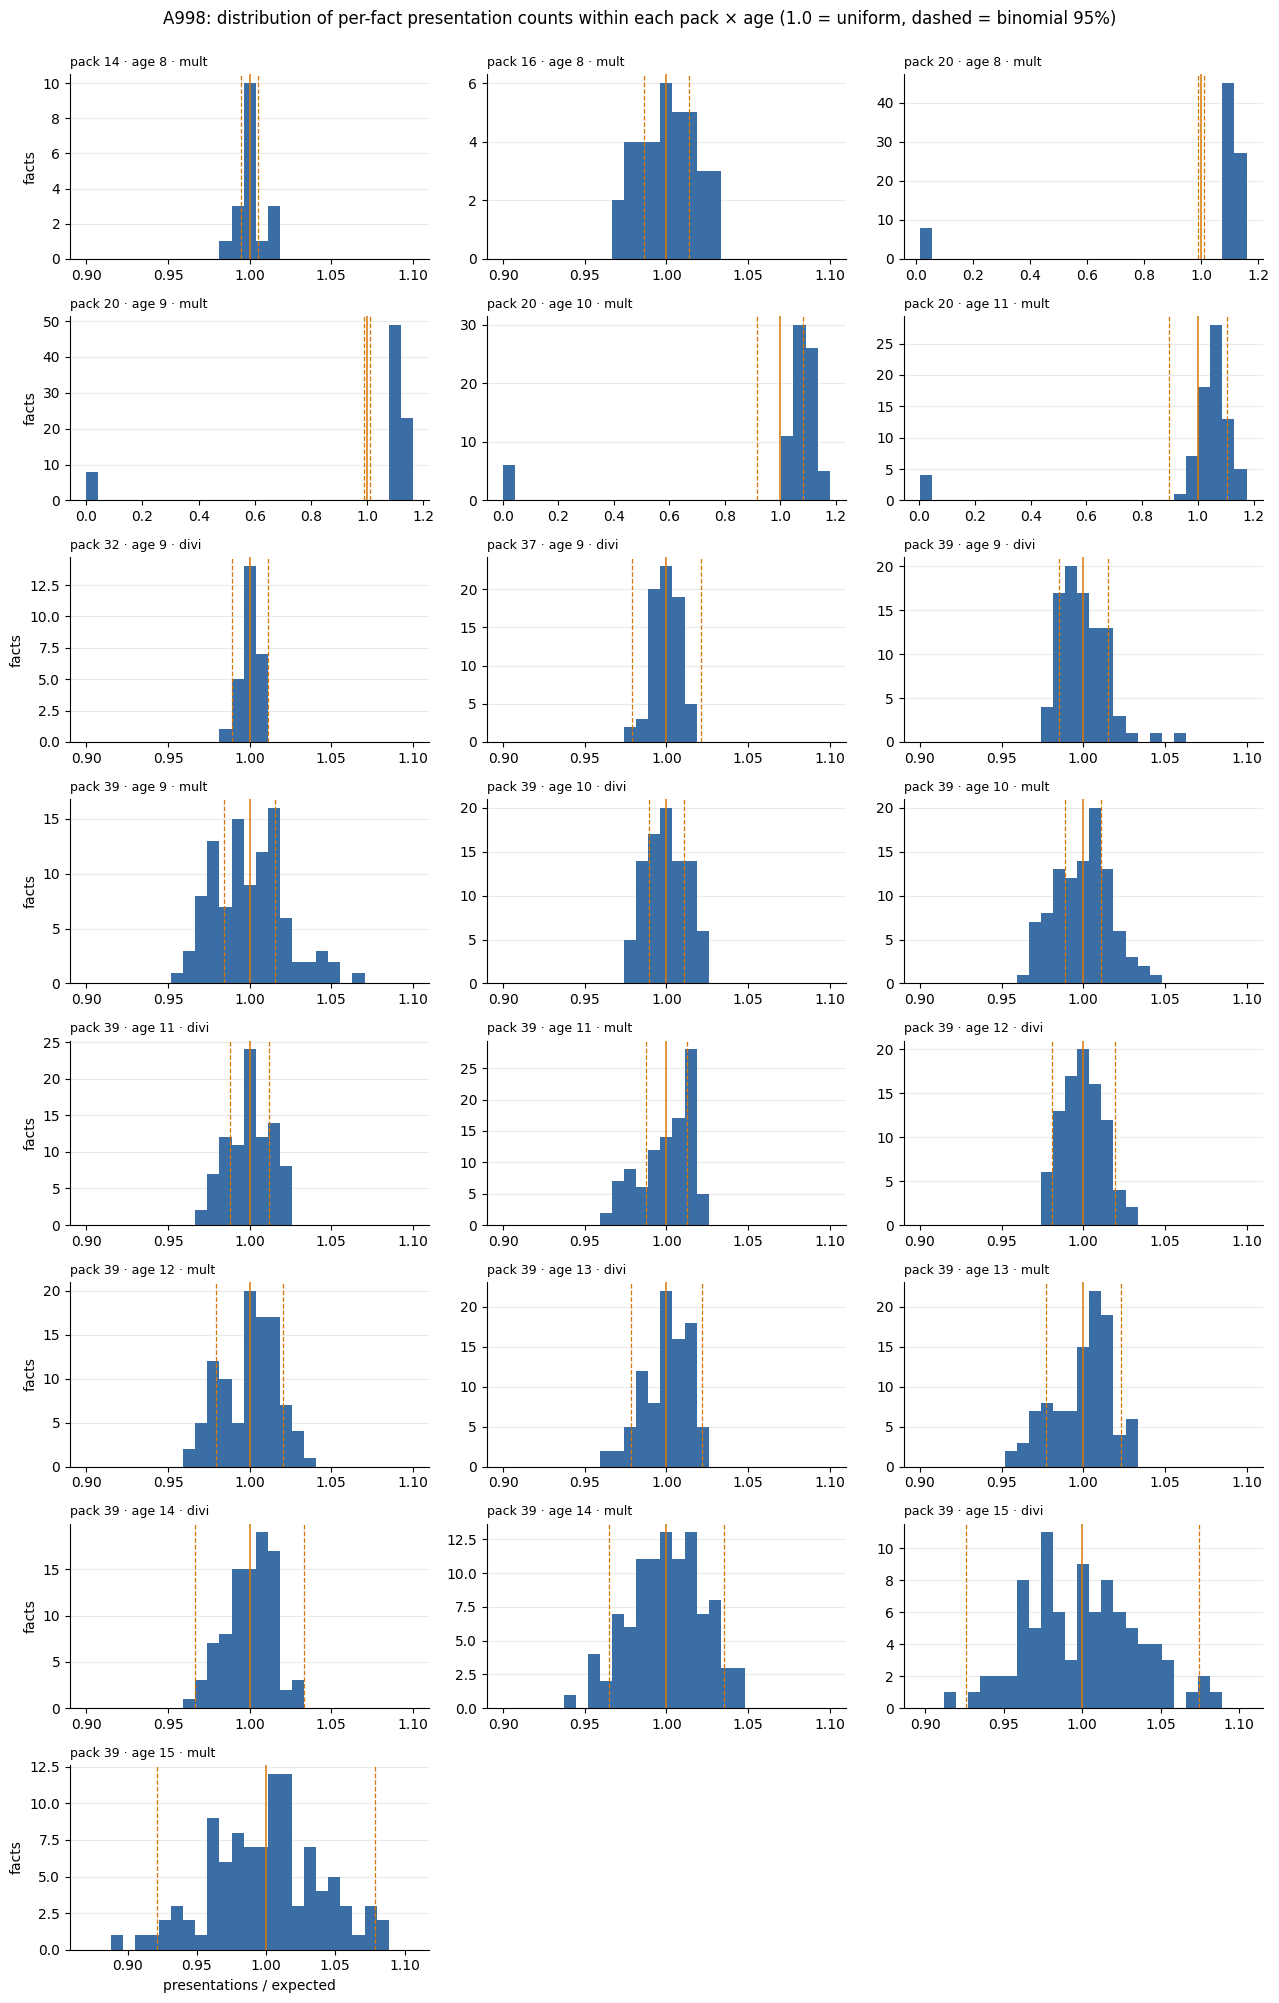

In [23]:
# --- the other reading of "histogram": the DISTRIBUTION of the counts ---------
# One histogram per (pack, age, op_type) of observed/expected across facts. A
# uniform draw gives a narrow bell around 1.0 whose width is set by the counts
# themselves (dashed = the 95% interval of the binomial null, same reference as
# the band above). Wider than the dashed lines = over-dispersed; a detached
# clump near 0 = facts that are not really in the pack.
def plot_ratio_hists(long=None, value=VALUE, min_total=MIN_TOTAL, ncols=3):
    long = pooled_all if long is None else long
    cells = [(k, g) for k, g in long.groupby(CELL_KEYS) if g["total"].iloc[0] >= min_total]
    nrows = int(np.ceil(len(cells) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 2.5 * nrows), squeeze=False)
    for ax, (key, g) in zip(axes.ravel(), cells):
        pack, age, op = key
        cv_null = float(np.sqrt((1 - 1 / g["n_facts"].iloc[0]) / g["expected"].iloc[0]))
        ax.hist(g["ratio"], bins=np.linspace(min(0.9, g["ratio"].min() * 0.98),
                                             max(1.1, g["ratio"].max() * 1.02), 28),
                color=FACT_BAR, linewidth=0)
        ax.axvline(1.0, color=BAND_COLOR, linewidth=1.1)
        for s in (-1.96, 1.96):
            ax.axvline(1 + s * cv_null, color=BAND_COLOR, linewidth=0.9, linestyle="--")
        ax.set_title(f"pack {pack} · age {age_label(age)} · {op[:4]}", loc="left", fontsize=9)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    for ax in axes.ravel()[len(cells):]:
        ax.set_axis_off()
    for ax in axes[-1]:
        ax.set_xlabel("presentations / expected")
    for row in axes:
        row[0].set_ylabel("facts")
    fig.suptitle("A998: distribution of per-fact presentation counts within each pack × age "
                 "(1.0 = uniform, dashed = binomial 95%)", y=0.999, fontsize=12)
    fig.tight_layout()
    fig.savefig(HERE / "plots" / "a998_fact_uniformity_ratio_hists.png", dpi=130, bbox_inches="tight")
    fig.savefig(HERE / "plots" / "a998_fact_uniformity_ratio_hists.pdf", bbox_inches="tight")
    plt.show()
    return fig

plot_ratio_hists()

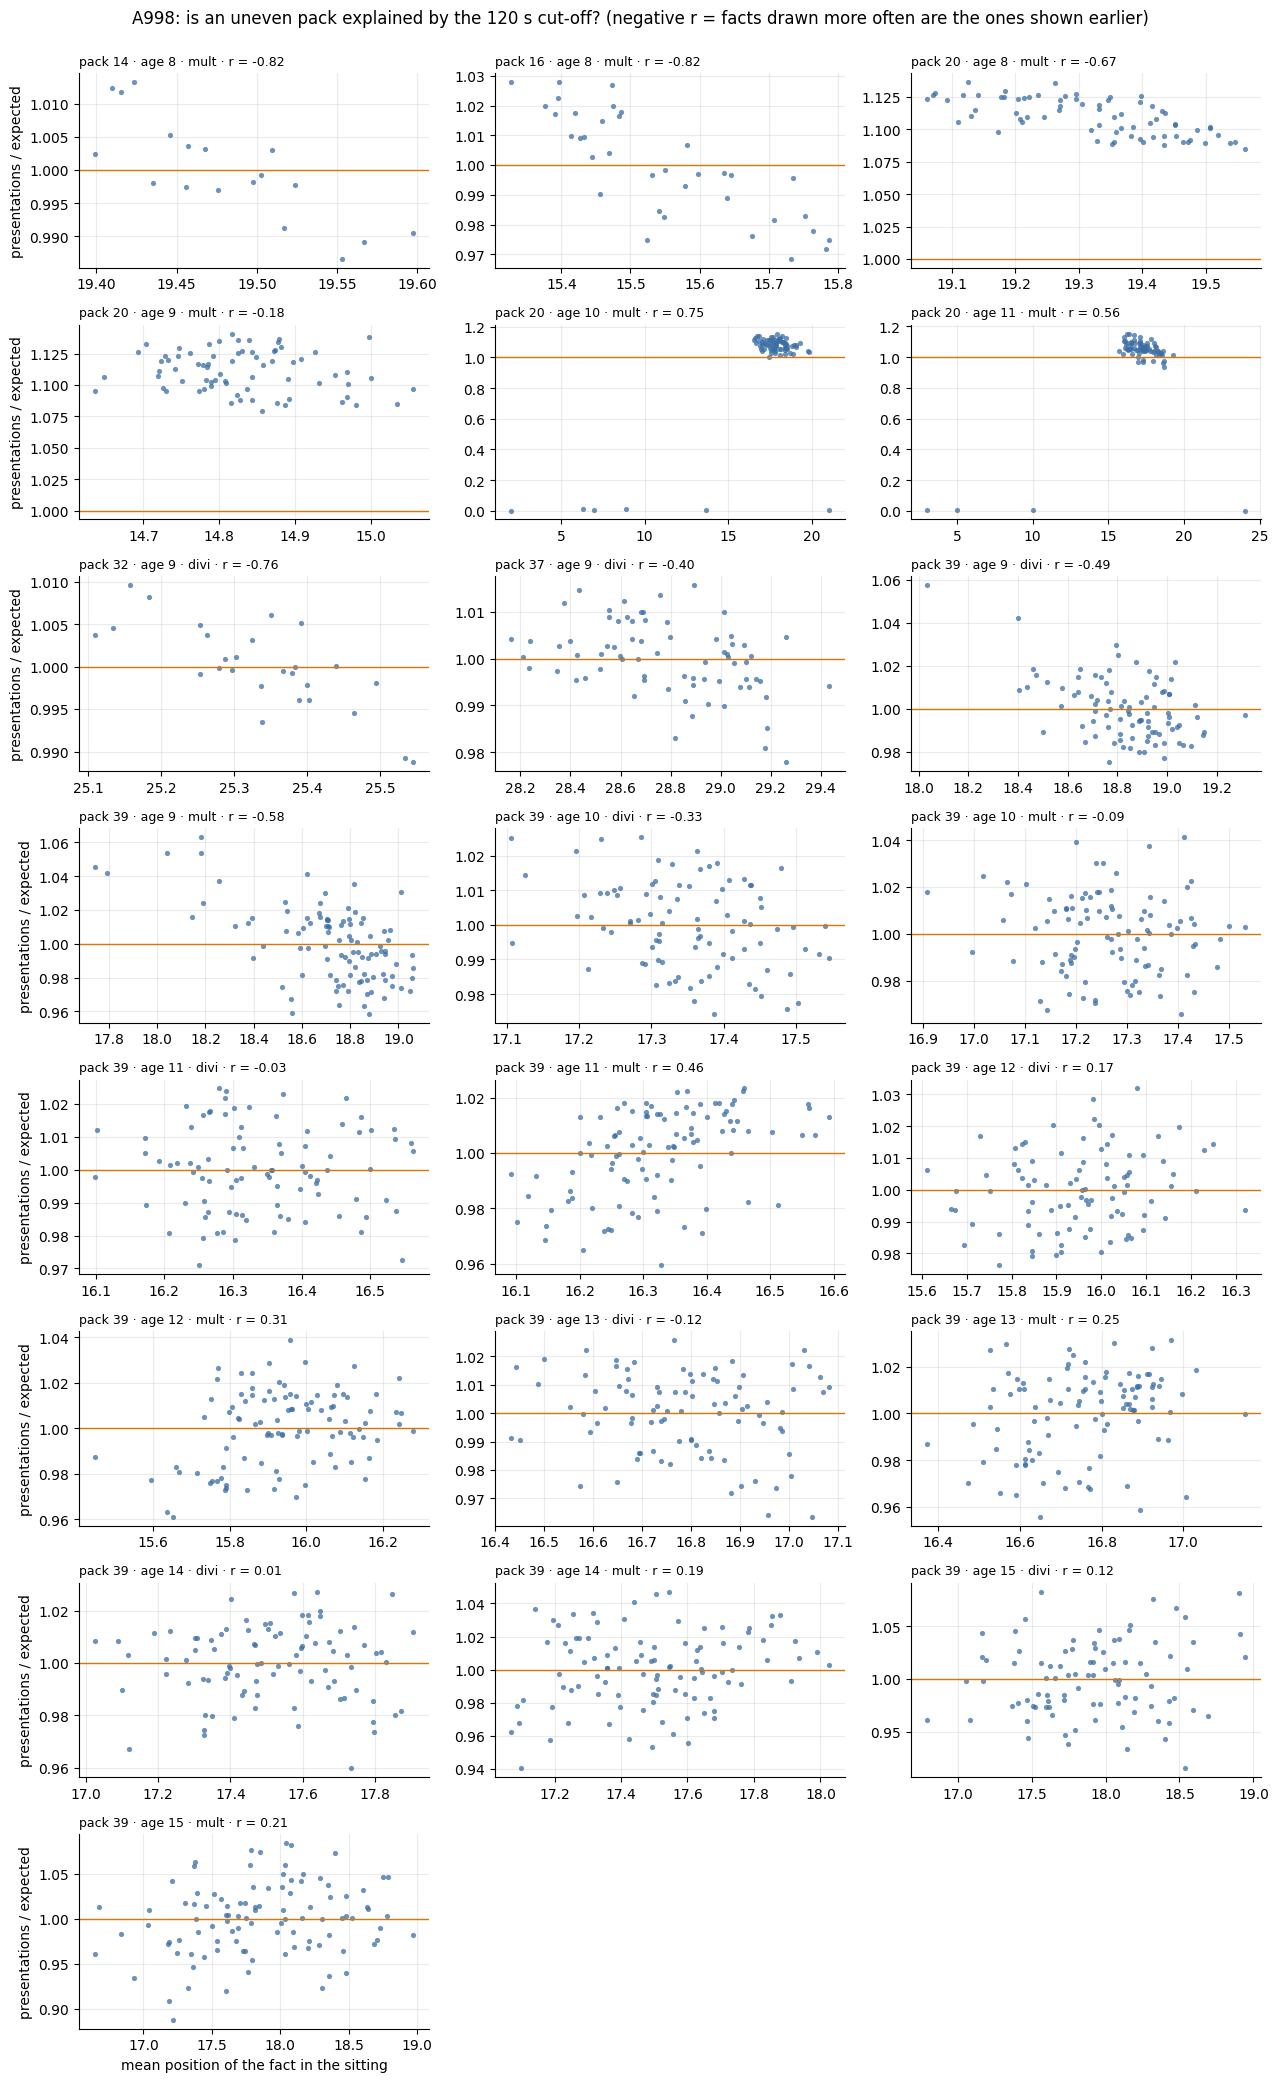

--- first item of a sitting vs all items: per-fact share difference ---
 activity_pack  age        op_type  n_first  max_abs_diff worst_fact
            14    8 multiplication   118336         0.030        4×2
            16    8 multiplication    40986         0.082        3×5
            20    8 multiplication   111120         0.072        4×6
            20    9 multiplication   117959         0.074        8×4
            20   10 multiplication     2078         0.569        2×6
            20   11 multiplication     1331         0.465        6×8
            32    9       division    31169         0.061       10:2
            37    9       division    20432         0.148       28:4
            39    9       division    67151         0.122        4:1
            39    9 multiplication    69036         1.096        2×5
            39   10       division   130871         0.082       40:5
            39   10 multiplication   135252         0.443        2×5
            39   11       divis

In [24]:
# --- if a pack is NOT uniform, is it the draw or the clock? -------------------
# The pack is timed, so nobody reaches the end of the item list. If the list is
# not reshuffled per pupil, facts that sit early are presented more often, and
# their mean position inside the sitting (mean_statement_idx) is lower. So:
#   downward slope of presentations vs mean position => truncation by the clock,
#     the draw itself can still be uniform over the pack;
#   flat cloud with vertical spread  => the draw is genuinely uneven.
# Both panels use the same cells as the histograms. r is Pearson's r over facts.
def plot_position_vs_count(long=None, value=VALUE, min_total=MIN_TOTAL, ncols=3):
    pos = (facts_raw.assign(w=facts_raw[value] * facts_raw["mean_statement_idx"])
           .groupby(CELL_KEYS + ["fact"], as_index=False)
           .agg(w=("w", "sum"), nn=(value, "sum")))
    pos["mean_idx"] = pos["w"] / pos["nn"]          # count-weighted mean position
    long = (pooled_all if long is None else long).merge(
        pos[CELL_KEYS + ["fact", "mean_idx"]], on=CELL_KEYS + ["fact"], how="left")

    cells = [(k, g) for k, g in long.groupby(CELL_KEYS) if g["total"].iloc[0] >= min_total]
    nrows = int(np.ceil(len(cells) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 2.6 * nrows), squeeze=False)
    for ax, (key, g) in zip(axes.ravel(), cells):
        pack, age, op = key
        g = g.dropna(subset=["mean_idx"])
        core = g[[(p, a, f) not in rare_facts
                  for p, a, f in zip(g["activity_pack"], g["age"], g["fact"])]]
        ax.scatter(core["mean_idx"], core["ratio"], s=14, color=FACT_BAR, alpha=0.75, linewidth=0)
        ax.axhline(1.0, color=BAND_COLOR, linewidth=1.0)
        r = core["mean_idx"].corr(core["ratio"]) if len(core) > 2 else np.nan
        ax.set_title(f"pack {pack} · age {age_label(age)} · {op[:4]} · r = {r:.2f}",
                     loc="left", fontsize=9)
        ax.grid(alpha=0.25)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
    for ax in axes.ravel()[len(cells):]:
        ax.set_axis_off()
    for ax in axes[-1]:
        ax.set_xlabel("mean position of the fact in the sitting")
    for row in axes:
        row[0].set_ylabel("presentations / expected")
    fig.suptitle("A998: is an uneven pack explained by the 120 s cut-off? "
                 "(negative r = facts drawn more often are the ones shown earlier)",
                 y=0.999, fontsize=12)
    fig.tight_layout()
    fig.savefig(HERE / "plots" / "a998_fact_uniformity_position.png", dpi=130, bbox_inches="tight")
    fig.savefig(HERE / "plots" / "a998_fact_uniformity_position.pdf", bbox_inches="tight")
    plt.show()
    return fig

plot_position_vs_count()

# --- and does the FIRST item of a sitting come from the same distribution? ----
# statement_idx = 0 is dropped by Decision #7 elsewhere. If it were a fixed
# warm-up fact it would be over-represented in n but not in n_excl_first, so the
# two rankings would disagree. Reported as the max |ratio difference| per cell.
first_cmp = facts_raw.groupby(CELL_KEYS + ["fact"], as_index=False)[["n", "n_excl_first"]].sum()
first_cmp["n_first"] = first_cmp["n"] - first_cmp["n_excl_first"]
chk = []
for key, g in first_cmp.groupby(CELL_KEYS):
    if g["n"].sum() < MIN_TOTAL:
        continue
    r_all   = g["n"] / g["n"].mean()
    r_first = g["n_first"] / g["n_first"].mean() if g["n_first"].sum() else np.nan * g["n"]
    chk.append(dict(zip(CELL_KEYS, key), n_first=int(g["n_first"].sum()),
                    max_abs_diff=round(float((r_first - r_all).abs().max()), 3),
                    worst_fact=g.loc[(r_first - r_all).abs().idxmax(), "fact"]))
print("--- first item of a sitting vs all items: per-fact share difference ---")
print(pd.DataFrame(chk).to_string(index=False))
print("\nSmall values (< ~0.1) mean the first item is drawn like any other and "
      "Decision #7 does not change which facts are over- or under-represented.")